# Building Your First Feedforward Neural Network

---

In the last walkthrough, we built a single artificial neuron. Today, we'll connect multiple neurons into layers and build a complete feedforward neural network. By the end, you'll understand how data flows through a network and how the network measures its mistakes.

## Part 1: Conceptual Review

### From One Neuron to Many

A single neuron can only draw **straight lines** to separate data. But real-world problems are rarely that simple!

**The Solution:** Stack neurons into **layers**, and stack layers into **networks**.

### The Feedforward Neural Network

```
INPUT LAYER → HIDDEN LAYER(S) → OUTPUT LAYER
```

- **Input Layer:** Receives your data (one neuron per feature)
- **Hidden Layer(s):** Where the magic happens — learns patterns
- **Output Layer:** Produces the prediction

**"Feedforward"** means data flows in one direction: forward through the network.

## Part 2: The Math Behind It

Let's trace through a tiny network by hand.

### Example: 2 inputs → 2 hidden neurons → 1 output

**Inputs:** `[0.5, 0.8]`

**Layer 1 Weights (2 hidden neurons, each needs 2 weights):**
```
Hidden Neuron 1: [0.1, 0.2]  (weights from input 1 and input 2)
Hidden Neuron 2: [0.3, 0.4]  (weights from input 1 and input 2)
```

**Layer 1 Biases:** `[0.1, 0.1]`

---

**Step 1: Calculate weighted sums for hidden layer**
```
Hidden 1: (0.5 × 0.1) + (0.8 × 0.2) + 0.1 = 0.05 + 0.16 + 0.1 = 0.31
Hidden 2: (0.5 × 0.3) + (0.8 × 0.4) + 0.1 = 0.15 + 0.32 + 0.1 = 0.57
```

**Step 2: Apply ReLU activation** (if negative → 0, if positive → keep it)
```
Hidden 1: max(0, 0.31) = 0.31
Hidden 2: max(0, 0.57) = 0.57
```

**Step 3: Pass to output layer**
```
Output weights: [0.5, 0.6]
Output bias: 0.1

Output: (0.31 × 0.5) + (0.57 × 0.6) + 0.1 = 0.155 + 0.342 + 0.1 = 0.597
```

**Final output: 0.597**

That's forward propagation! Data flows forward, layer by layer.

## Part 3: Activation Functions

Activation functions add **non-linearity** — without them, stacking layers would be pointless (linear × linear = still linear).

Let's first **visualize** the three most common ones, then we'll build them!

In [1]:
# First, let's import our tools
import numpy as np
import matplotlib.pyplot as plt

print("Ready to build our neural network!")

Ready to build our neural network!


### Visualizing Activation Functions

Before we build them, let's see what these functions look like!

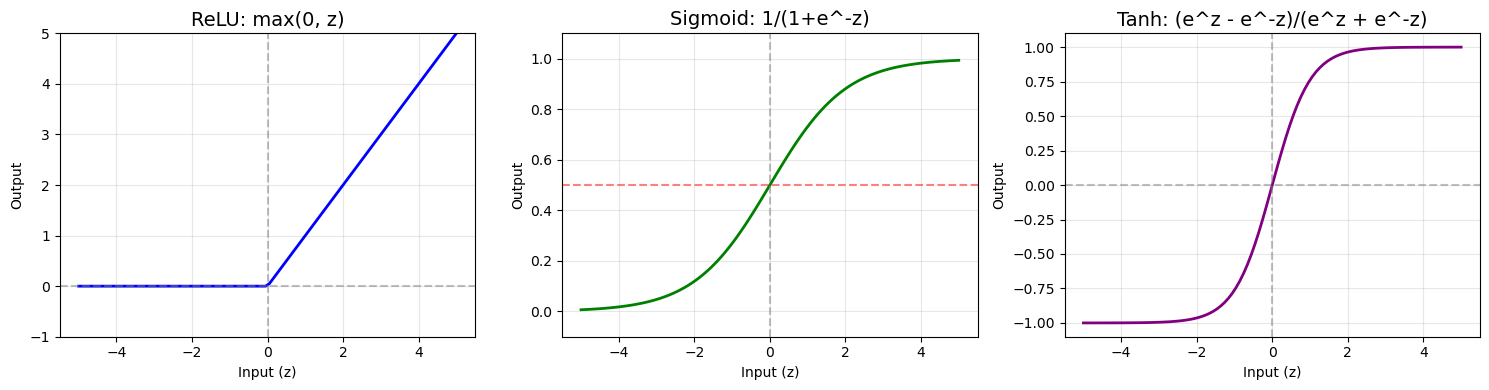

Key observations:
  - ReLU: Simple, fast, most popular for hidden layers
  - Sigmoid: Outputs 0-1, good for probability/binary classification
  - Tanh: Outputs -1 to 1, zero-centered


In [2]:
# Create a range of values
z = np.linspace(-5, 5, 100)

# Calculate outputs for each activation function
relu_out = np.maximum(0, z)  # ReLU
sigmoid_out = 1 / (1 + np.exp(-z))  # Sigmoid
tanh_out = np.tanh(z)  # Tanh

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU
axes[0].plot(z, relu_out, 'b-', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('ReLU: max(0, z)', fontsize=14)
axes[0].set_xlabel('Input (z)')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1, 5)

# Sigmoid
axes[1].plot(z, sigmoid_out, 'g-', linewidth=2)
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='y=0.5')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Sigmoid: 1/(1+e^-z)', fontsize=14)
axes[1].set_xlabel('Input (z)')
axes[1].set_ylabel('Output')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

# Tanh
axes[2].plot(z, tanh_out, 'purple', linewidth=2)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Tanh: (e^z - e^-z)/(e^z + e^-z)', fontsize=14)
axes[2].set_xlabel('Input (z)')
axes[2].set_ylabel('Output')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - ReLU: Simple, fast, most popular for hidden layers")
print("  - Sigmoid: Outputs 0-1, good for probability/binary classification")
print("  - Tanh: Outputs -1 to 1, zero-centered")

### Now Let's Build Them!

Now that we've seen what they look like, let's implement each one.

In [3]:
# ReLU: Rectified Linear Unit
# Rule: If negative, output 0. If positive, keep it.

def relu(z):
    """ReLU activation: max(0, z)"""
    return np.maximum(0, z)

# Test it
test_values = np.array([-2, -1, 0, 1, 2])
print("ReLU Test:")
print(f"  Input:  {test_values}")
print(f"  Output: {relu(test_values)}")

ReLU Test:
  Input:  [-2 -1  0  1  2]
  Output: [0 0 0 1 2]


In [4]:
# Sigmoid: Squashes values to range (0, 1)
# Great for probabilities!

def sigmoid(z):
    """Sigmoid activation: 1 / (1 + e^-z)"""
    return 1 / (1 + np.exp(-z))

# Test it
print("Sigmoid Test:")
print(f"  Input:  {test_values}")
print(f"  Output: {np.round(sigmoid(test_values), 3)}")
print("\nNotice: All outputs are between 0 and 1!")

Sigmoid Test:
  Input:  [-2 -1  0  1  2]
  Output: [0.119 0.269 0.5   0.731 0.881]

Notice: All outputs are between 0 and 1!


In [5]:
# Tanh: Squashes values to range (-1, 1)
# Like sigmoid, but centered at 0

def tanh(z):
    """Tanh activation: (e^z - e^-z) / (e^z + e^-z)"""
    return np.tanh(z)  # NumPy has this built in!

# Test it
print("Tanh Test:")
print(f"  Input:  {test_values}")
print(f"  Output: {np.round(tanh(test_values), 3)}")
print("\nNotice: Outputs range from -1 to 1, centered at 0!")

Tanh Test:
  Input:  [-2 -1  0  1  2]
  Output: [-0.964 -0.762  0.     0.762  0.964]

Notice: Outputs range from -1 to 1, centered at 0!


## Part 4: Building a Layer of Neurons

Now let's build a complete layer! A layer is just multiple neurons working in parallel.

First, let's visualize what our network will look like!

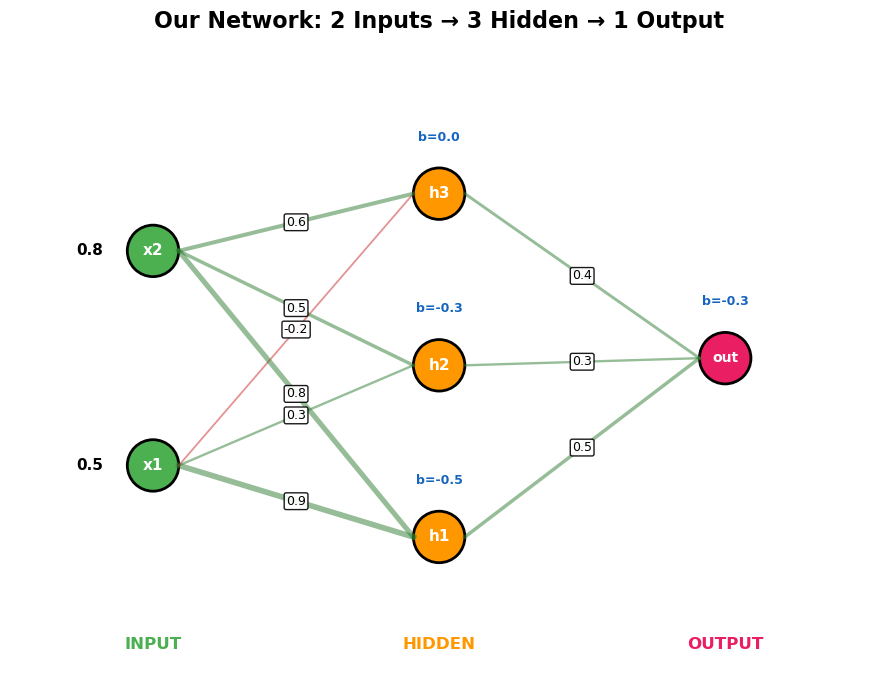

In [6]:
# ============================================================
# NOTE: You don't need to understand this visualization code!
# It's just here to draw the network diagram for us.
# ============================================================

def draw_full_network(inputs, W1, b1, W2, b2):
    """Draw a visualization of a complete neural network."""
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(-0.5, 5.5)
    ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title("Our Network: 2 Inputs → 3 Hidden → 1 Output", fontsize=16, fontweight='bold')
    
    input_x, hidden_x, output_x = 0.5, 2.5, 4.5
    input_positions = [(input_x, 1.0 + i * 1.5) for i in range(2)]
    hidden_positions = [(hidden_x, 0.5 + i * 1.2) for i in range(3)]
    output_positions = [(output_x, 1.75)]
    
    # Draw connections: Input → Hidden
    for i, (ix, iy) in enumerate(input_positions):
        for j, (hx, hy) in enumerate(hidden_positions):
            weight = W1[j, i]
            ax.plot([ix + 0.18, hx - 0.18], [iy, hy], color='#2E7D32' if weight > 0 else '#C62828', 
                   linewidth=abs(weight) * 4 + 0.5, alpha=0.5)
            ax.annotate(f'{weight:.1f}', ((ix + hx) / 2, (iy + hy) / 2), fontsize=9, ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.9))
    
    # Draw connections: Hidden → Output
    for j, (hx, hy) in enumerate(hidden_positions):
        for k, (ox, oy) in enumerate(output_positions):
            weight = W2[k, j]
            ax.plot([hx + 0.18, ox - 0.18], [hy, oy], color='#2E7D32' if weight > 0 else '#C62828', 
                   linewidth=abs(weight) * 4 + 0.5, alpha=0.5)
            ax.annotate(f'{weight:.1f}', ((hx + ox) / 2, (hy + oy) / 2), fontsize=9, ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.9))
    
    # Draw neurons
    for i, (x, y) in enumerate(input_positions):
        ax.add_patch(plt.Circle((x, y), 0.18, color='#4CAF50', ec='black', linewidth=2))
        ax.text(x, y, f'x{i+1}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(x - 0.35, y, f'{inputs[i]}', ha='right', va='center', fontsize=11, fontweight='bold')
    
    for j, (x, y) in enumerate(hidden_positions):
        ax.add_patch(plt.Circle((x, y), 0.18, color='#FF9800', ec='black', linewidth=2))
        ax.text(x, y, f'h{j+1}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(x, y + 0.35, f'b={b1[j]}', ha='center', va='bottom', fontsize=9, color='#1565C0', fontweight='bold')
    
    for k, (x, y) in enumerate(output_positions):
        ax.add_patch(plt.Circle((x, y), 0.18, color='#E91E63', ec='black', linewidth=2))
        ax.text(x, y, 'out', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        ax.text(x, y + 0.35, f'b={b2[k]}', ha='center', va='bottom', fontsize=9, color='#1565C0', fontweight='bold')
    
    ax.text(input_x, -0.2, 'INPUT', ha='center', va='top', fontsize=12, fontweight='bold', color='#4CAF50')
    ax.text(hidden_x, -0.2, 'HIDDEN', ha='center', va='top', fontsize=12, fontweight='bold', color='#FF9800')
    ax.text(output_x, -0.2, 'OUTPUT', ha='center', va='top', fontsize=12, fontweight='bold', color='#E91E63')
    plt.tight_layout()
    plt.show()

# Our network parameters (same as we'll use later)
inputs = np.array([0.5, 0.8])
W1 = np.array([[0.9, 0.8], [0.3, 0.5], [-0.2, 0.6]])
b1 = np.array([-0.5, -0.3, 0.0])
W2 = np.array([[0.5, 0.3, 0.4]])
b2 = np.array([-0.3])

draw_full_network(inputs, W1, b1, W2, b2)

### Understanding Weight Matrices

When we have multiple neurons in a layer, we organize weights into a **matrix**.

**Shape rule:** `(number of neurons in this layer, number of inputs)`

Each **row** represents one neuron's weights.

In [22]:
# Weight matrix for hidden layer: 2 inputs → 3 hidden neurons
# Shape: (3 neurons, 2 inputs) = (3, 2)

W1 = np.array([
    [0.1, 0.2],   # Neuron 1's weights: from input 1 and input 2
    [0.3, 0.4],   # Neuron 2's weights: from input 1 and input 2
    [0.5, 0.6]    # Neuron 3's weights: from input 1 and input 2
])

print("Weight Matrix W1:")
print(W1)
print(f"\nShape: {W1.shape} (3 neurons, 2 inputs per neuron)")
print("\nEach row is one neuron's weights!")

Weight Matrix W1:
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]]

Shape: (3, 2) (3 neurons, 2 inputs per neuron)

Each row is one neuron's weights!


In [23]:
# Biases: one per neuron
b1 = np.array([0.1, 0.1, 0.1])

print("Biases b1:", b1)
print(f"Shape: {b1.shape} (one bias per neuron)")

Biases b1: [0.1 0.1 0.1]
Shape: (3,) (one bias per neuron)


In [24]:
# Calculate the layer output!
# Matrix multiplication + bias

z1 = np.dot(W1, inputs) + b1

print("Computing hidden layer:")
print(f"  z = W1 @ inputs + b1")
print(f"  z = {W1.shape} @ {inputs.shape} + {b1.shape}")
print(f"\nWeighted sums (before activation): {z1}")

Computing hidden layer:
  z = W1 @ inputs + b1
  z = (3, 2) @ (2,) + (3,)

Weighted sums (before activation): [0.31 0.57 0.83]


In [25]:
# Let's see the math for each neuron
print("Breaking it down neuron by neuron:")
print("=" * 50)

for i in range(3):
    weighted_sum = inputs[0] * W1[i, 0] + inputs[1] * W1[i, 1] + b1[i]
    print(f"\nNeuron {i+1}:")
    print(f"  ({inputs[0]} × {W1[i,0]}) + ({inputs[1]} × {W1[i,1]}) + {b1[i]}")
    print(f"  = {inputs[0] * W1[i,0]:.2f} + {inputs[1] * W1[i,1]:.2f} + {b1[i]}")
    print(f"  = {weighted_sum:.2f}")

Breaking it down neuron by neuron:

Neuron 1:
  (0.5 × 0.1) + (0.8 × 0.2) + 0.1
  = 0.05 + 0.16 + 0.1
  = 0.31

Neuron 2:
  (0.5 × 0.3) + (0.8 × 0.4) + 0.1
  = 0.15 + 0.32 + 0.1
  = 0.57

Neuron 3:
  (0.5 × 0.5) + (0.8 × 0.6) + 0.1
  = 0.25 + 0.48 + 0.1
  = 0.83


In [26]:
# Apply ReLU activation
a1 = relu(z1)

print("Applying ReLU activation:")
print(f"  Before ReLU: {z1}")
print(f"  After ReLU:  {a1}")
print("\nThese are now the OUTPUTS of our hidden layer!")

Applying ReLU activation:
  Before ReLU: [0.31 0.57 0.83]
  After ReLU:  [0.31 0.57 0.83]

These are now the OUTPUTS of our hidden layer!


## Part 5: Forward Propagation - The Complete Picture

Now let's build a complete network and trace data through every step!

**Our network:** 2 inputs → 3 hidden neurons → 1 output

In [27]:
# Complete network setup
print("=" * 50)
print("NETWORK ARCHITECTURE")
print("=" * 50)
print("\n  Input Layer:  2 neurons (features)")
print("  Hidden Layer: 3 neurons (ReLU activation)")
print("  Output Layer: 1 neuron (Sigmoid activation)")
print("\n" + "=" * 50)

NETWORK ARCHITECTURE

  Input Layer:  2 neurons (features)
  Hidden Layer: 3 neurons (ReLU activation)
  Output Layer: 1 neuron (Sigmoid activation)



In [28]:
# Initialize all weights and biases

# Input
X = np.array([0.5, 0.8])

# Layer 1: Input → Hidden (2 inputs, 3 hidden neurons)
# These weights make the network sensitive to BOTH studying AND sleeping
W1 = np.array([
    [0.9, 0.8],    # Neuron 1: values both study and sleep
    [0.3, 0.5],    # Neuron 2: slightly more sleep-focused
    [-0.2, 0.6]    # Neuron 3: sleep helps, but too much study without sleep hurts
])
b1 = np.array([-0.5, -0.3, 0.0]) 

# Layer 2: Hidden → Output (3 hidden neurons, 1 output)
W2 = np.array([[0.5, 0.3, 0.4]])
b2 = np.array([-0.3])  # Negative bias = network is "skeptical" by default

print("Network Parameters:")
print(f"  Input X: {X}")
print(f"  W1 shape: {W1.shape} (3 hidden neurons × 2 inputs)")
print(f"  b1 shape: {b1.shape}")
print(f"  W2 shape: {W2.shape} (1 output × 3 hidden)")
print(f"  b2 shape: {b2.shape}")

Network Parameters:
  Input X: [0.5 0.8]
  W1 shape: (3, 2) (3 hidden neurons × 2 inputs)
  b1 shape: (3,)
  W2 shape: (1, 3) (1 output × 3 hidden)
  b2 shape: (1,)


In [29]:
# FORWARD PROPAGATION - Step by Step

print("=" * 50)
print("FORWARD PROPAGATION")
print("=" * 50)

# Step 1: Input to Hidden Layer
print("\n--- STEP 1: Input → Hidden Layer ---")
z1 = np.dot(W1, X) + b1
print(f"Weighted sum (z1): {z1}")

a1 = relu(z1)
print(f"After ReLU (a1):   {a1}")

# Step 2: Hidden to Output Layer
print("\n--- STEP 2: Hidden → Output Layer ---")
z2 = np.dot(W2, a1) + b2
print(f"Weighted sum (z2): {z2}")

output = sigmoid(z2)
print(f"After Sigmoid:     {output}")

print("\n" + "=" * 50)
print(f"FINAL PREDICTION: {output[0]:.4f}")
print("=" * 50)

FORWARD PROPAGATION

--- STEP 1: Input → Hidden Layer ---
Weighted sum (z1): [0.59 0.25 0.38]
After ReLU (a1):   [0.59 0.25 0.38]

--- STEP 2: Hidden → Output Layer ---
Weighted sum (z2): [0.222]
After Sigmoid:     [0.55527318]

FINAL PREDICTION: 0.5553


### Let's Wrap This Into a Function

In [30]:
def forward_propagation(X, W1, b1, W2, b2, verbose=False):
    """
    Perform forward propagation through a 2-layer network.
    
    Parameters:
    - X: Input features
    - W1, b1: Hidden layer weights and biases
    - W2, b2: Output layer weights and biases
    - verbose: If True, print intermediate values
    
    Returns:
    - output: The network's prediction
    - cache: Dictionary of intermediate values (useful for backprop later!)
    """
    # Hidden layer
    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    
    # Output layer
    z2 = np.dot(W2, a1) + b2
    output = sigmoid(z2)
    
    if verbose:
        print(f"Input: {X}")
        print(f"Hidden (z1): {z1} → (a1): {a1}")
        print(f"Output (z2): {z2} → prediction: {output}")
    
    cache = {'z1': z1, 'a1': a1, 'z2': z2, 'output': output}
    return output, cache

# Test it
prediction, _ = forward_propagation(X, W1, b1, W2, b2, verbose=True)

Input: [0.5 0.8]
Hidden (z1): [0.59 0.25 0.38] → (a1): [0.59 0.25 0.38]
Output (z2): [0.222] → prediction: [0.55527318]


### Experiment: Different Inputs, Same Network

In [31]:
# Let's see how different inputs produce different outputs
print("=" * 50)
print("EXPERIMENT: Same network, different inputs")
print("=" * 50)

test_inputs = [
    np.array([0.0, 0.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 1.0]),
    np.array([1.0, 1.0]),
    np.array([0.5, 0.5]),
]

for inp in test_inputs:
    pred, _ = forward_propagation(inp, W1, b1, W2, b2)
    print(f"Input: {inp} → Output: {pred[0]:.4f}")

EXPERIMENT: Same network, different inputs
Input: [0. 0.] → Output: 0.4256
Input: [1. 0.] → Output: 0.4750
Input: [0. 1.] → Output: 0.5374
Input: [1. 1.] → Output: 0.6479
Input: [0.5 0.5] → Output: 0.4963


## Part 6: Loss Functions - Measuring Mistakes

The network made a prediction. But how do we know if it's good or bad?

**Loss functions** measure the difference between our prediction and the true answer.

- **Lower loss = better predictions**
- **Higher loss = worse predictions**

### Mean Squared Error (MSE)

Used for **regression** (predicting continuous values like prices, temperatures).

**Formula:** `MSE = average of (prediction - actual)²`

In [32]:
def mean_squared_error(y_true, y_pred):
    """
    Calculate Mean Squared Error.
    
    Parameters:
    - y_true: Actual values
    - y_pred: Predicted values
    
    Returns:
    - MSE loss
    """
    return np.mean((y_true - y_pred) ** 2)

# Example
actual = np.array([1.0, 0.0, 1.0, 0.0])
predicted = np.array([0.9, 0.1, 0.8, 0.2])

mse = mean_squared_error(actual, predicted)

print("MSE Example:")
print(f"  Actual:    {actual}")
print(f"  Predicted: {predicted}")
print(f"  Errors:    {actual - predicted}")
print(f"  Squared:   {(actual - predicted) ** 2}")
print(f"  MSE Loss:  {mse:.4f}")

MSE Example:
  Actual:    [1. 0. 1. 0.]
  Predicted: [0.9 0.1 0.8 0.2]
  Errors:    [ 0.1 -0.1  0.2 -0.2]
  Squared:   [0.01 0.01 0.04 0.04]
  MSE Loss:  0.0250


### Binary Cross-Entropy

Used for **binary classification** (yes/no, cat/dog, spam/not spam).

**Formula:** `BCE = -[y·log(p) + (1-y)·log(1-p)]`

Where `y` is the true label (0 or 1) and `p` is the predicted probability.

In [37]:
def binary_cross_entropy(y_true, y_pred):
    """
    Calculate Binary Cross-Entropy loss.
    
    Parameters:
    - y_true: Actual labels (0 or 1)
    - y_pred: Predicted probabilities (0 to 1)
    
    Returns:
    - BCE loss
    """
    # Add small epsilon to avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Example
actual = np.array([1.0, 0.0, 1.0, 0.0])
predicted = np.array([0.9, 0.1, 0.8, 0.2])

bce = binary_cross_entropy(actual, predicted)

print("Binary Cross-Entropy Example:")
print(f"  Actual:    {actual}")
print(f"  Predicted: {predicted}")
print(f"  BCE Loss:  {bce:.4f}")

Binary Cross-Entropy Example:
  Actual:    [1. 0. 1. 0.]
  Predicted: [0.9 0.1 0.8 0.2]
  BCE Loss:  0.1643


## Part 7: Putting It All Together

Let's do a complete forward pass with loss calculation!

**Scenario:** We're predicting if a student will pass an exam based on:
- Hours studied (normalized 0-1)
- Hours of sleep (normalized 0-1)

In [38]:
# Student data: [hours_studied, hours_sleep]
students = np.array([
    [0.8, 0.7],  # Student 1: studied a lot, good sleep
    [0.2, 0.3],  # Student 2: barely studied, little sleep
    [0.6, 0.8],  # Student 3: moderate study, great sleep
    [0.9, 0.2],  # Student 4: crammed all night, no sleep
])

# True outcomes: 1 = passed, 0 = failed
actual_results = np.array([1, 0, 1, 0])

print("Student Data:")
print("  [Study Hours, Sleep Hours] → Passed?")
for i, (student, result) in enumerate(zip(students, actual_results)):
    print(f"  Student {i+1}: {student} → {'Passed' if result else 'Failed'}")

Student Data:
  [Study Hours, Sleep Hours] → Passed?
  Student 1: [0.8 0.7] → Passed
  Student 2: [0.2 0.3] → Failed
  Student 3: [0.6 0.8] → Passed
  Student 4: [0.9 0.2] → Failed


In [35]:
# Run each student through our network
print("=" * 50)
print("NETWORK PREDICTIONS")
print("=" * 50)

predictions = []
for i, student in enumerate(students):
    pred, _ = forward_propagation(student, W1, b1, W2, b2)
    predictions.append(pred[0])
    
    actual = actual_results[i]
    print(f"\nStudent {i+1}: {student}")
    print(f"  Predicted: {pred[0]:.4f}")
    print(f"  Actual:    {actual} ({'Passed' if actual else 'Failed'})")
    print(f"  Network says: {'Likely Pass' if pred[0] > 0.5 else 'Likely Fail'}")

predictions = np.array(predictions)

NETWORK PREDICTIONS

Student 1: [0.8 0.7]
  Predicted: 0.5698
  Actual:    1 (Passed)
  Network says: Likely Pass

Student 2: [0.2 0.3]
  Predicted: 0.4393
  Actual:    0 (Failed)
  Network says: Likely Fail

Student 3: [0.6 0.8]
  Predicted: 0.5666
  Actual:    1 (Passed)
  Network says: Likely Pass

Student 4: [0.9 0.2]
  Predicted: 0.4890
  Actual:    0 (Failed)
  Network says: Likely Fail


In [36]:
# Calculate the total loss
print("=" * 50)
print("LOSS CALCULATION")
print("=" * 50)

mse = mean_squared_error(actual_results, predictions)
bce = binary_cross_entropy(actual_results, predictions)

print(f"\nPredictions: {np.round(predictions, 4)}")
print(f"Actual:      {actual_results}")
print(f"\nMean Squared Error:    {mse:.4f}")
print(f"Binary Cross-Entropy:  {bce:.4f}")
print("\nThese numbers tell us how 'wrong' our network is.")
print("Training = adjusting weights to make these numbers smaller!")

LOSS CALCULATION

Predictions: [0.5698 0.4393 0.5666 0.489 ]
Actual:      [1 0 1 0]

Mean Squared Error:    0.2013
Binary Cross-Entropy:  0.5951

These numbers tell us how 'wrong' our network is.
Training = adjusting weights to make these numbers smaller!


### What Happens During Training?

We just did **one forward pass**. In real training:

1. **Forward pass** → Get predictions
2. **Calculate loss** → How wrong are we?
3. **Backpropagation** → Figure out which weights caused the error
4. **Update weights** → Adjust to reduce loss
5. **Repeat** thousands of times!

**Next class:** We'll dive deep into the math of backpropagation!

## Part 8: Key Takeaways

### What We Learned:

1. **Neural networks are layers of neurons**
   - Input layer receives data
   - Hidden layers learn patterns
   - Output layer makes predictions

2. **Forward propagation is just math**
   - Weighted sum: `z = W @ x + b`
   - Activation: `a = activation(z)`
   - Repeat for each layer!

3. **Activation functions add non-linearity**
   - ReLU: Simple, popular for hidden layers
   - Sigmoid: Good for binary classification
   - Tanh: Zero-centered alternative

4. **Loss functions measure mistakes**
   - MSE: For regression problems
   - Cross-Entropy: For classification problems
   - Lower loss = better predictions

### What's Next?

**Backpropagation:** How does the network actually *learn*? We'll trace error signals backward through the network to understand how weights get updated.

---

**Congratulations!** You now understand how data flows through a neural network and how we measure its performance!